## Normalização Inglês

In [ ]:
import re, unicodedata, nltk
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Boa prática: instanciar sets e classes fora da função para economizar processamento
stop_words_set = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_text_and_extract_domains(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Extrair domínios (busca por padrões como site.com, www.site.com.br, etc.)
    # O Regex pega blocos separados por ponto terminando com 2 ou mais letras
    domain_pattern = r'\b(?:[a-z0-9-]+\.)+[a-z]{2,}\b'
    extracted_domains = re.findall(domain_pattern, text)
    # Remove duplicatas da lista caso o mesmo domínio apareça várias vezes
    extracted_domains = list(dict.fromkeys(extracted_domains))

    # 3. Remover Links, Emails e Domínios do texto
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text) # Remove links inteiros (com path)
    text = re.sub(r'\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b', '', text) # Remove e-mails
    text = re.sub(domain_pattern, '', text) # Remove domínios que sobraram soltos

    # 4. Remove Unicode accents
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 5. Remove punctuation and special characters
    # ATENÇÃO: Adicionei o '0-9' para não apagar os números ainda.
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # 6. Remove numerais sem contexto (números isolados)
    # Mantém números dentro de palavras (ex: "mp3", "b2b") mas apaga isolados (ex: "temos 2 gatos").
    # Se quiser apagar TUDO que for número, basta remover o '0-9' do passo 5 e deletar este passo 6.
    text = re.sub(r'\b\d+\b', '', text)

    # 7. Remove palavras ou expressões repetidas em sequência
    text = re.sub(r'\b(.+?)(?:\s+\1\b)+', r'\1', text)

    # 8. Lemmatize words (using NLTK)
    words = text.split()
    normalized = [lemmatizer.lemmatize(w) for w in words if w not in stop_words_set]

    # Retorna uma tupla: o texto limpo e a lista de domínios
    return " ".join(normalized), extracted_domains

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Normalização Português

In [ ]:
import re, unicodedata, nltk
from nltk.corpus import stopwords

# -------------------------------------------------------------------
# OTIMIZAÇÃO E AJUSTE DE CONTEXTO NARRATIVO
# -------------------------------------------------------------------

# 1. Pegamos a lista padrão de stopwords
stop_words_pt = set(stopwords.words('portuguese'))

# 2. Criamos uma lista de palavras que NUNCA devem ser apagadas,
# pois elas definem o sentido e a narrativa do texto.
palavras_para_manter = {'não', 'nao', 'nem', 'nunca', 'jamais', 'nada', 'vocês', 'voces'}

# 3. Retiramos essas palavras cruciais da lista de stopwords
stop_words_pt = stop_words_pt - palavras_para_manter

# 4. Removemos os acentos do que sobrou na lista de stopwords para o match funcionar
stop_words_pt_sem_acento = set(
    unicodedata.normalize('NFKD', w).encode('ascii', 'ignore').decode('utf-8')
    for w in stop_words_pt
)

def normalize_text_narrative_pt(text):
    text = str(text).lower()

    # 1. Extrair domínios
    domain_pattern = r'\b(?:[a-z0-9-]+\.)+[a-z]{2,}\b'
    extracted_domains = re.findall(domain_pattern, text)
    extracted_domains = list(dict.fromkeys(extracted_domains))

    # 2. Remover Links, Emails e Domínios
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    text = re.sub(r'\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b', '', text)
    text = re.sub(domain_pattern, '', text)

    # 3. Remover Acentos
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 4. Remover pontuação (Mantendo letras e NÚMEROS)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # 5. Remover numerais isolados
    text = re.sub(r'\b\d+\b', '', text)

    # 6. Remover repetições em sequência
    text = re.sub(r'\b(.+?)(?:\s+\1\b)+', r'\1', text)

    # 7. Tokenização e Remoção Inteligente de Stopwords (SEM STEMMER)
    words = text.split()
    normalized = [w for w in words if w not in stop_words_pt_sem_acento]

    return " ".join(normalized), extracted_domains

## Comentários em Inglês

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file
file_path = '/content/drive/MyDrive/projeto_youtube/comentarios_en/comments_cp_en.csv'

# Read the CSV file into a pandas DataFrame
try:
    # Added engine='python' for more robust parsing and on_bad_lines='skip' to bypass malformed rows
    df_comments_en = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
    print(f"Successfully loaded {len(df_comments_en)} rows from comments_cp_en.csv")
    print(df_comments_en.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please check the path and ensure Google Drive is mounted correctly.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded 1777557 rows from comments_cp_en.csv
      video_id                  comment_id parent_id  author_display_name  \
0  --S9jPwhDlI  Ugxy6wDarK79J2BNhB54AaABAg       NaN            @LexClips   
1  --S9jPwhDlI  UgxQWBEPodHevEhSczl4AaABAg       NaN              @dovasd   
2  --S9jPwhDlI  UgxJINzk0QHcJwiZdX94AaABAg       NaN       @michaeltse321   
3  --S9jPwhDlI  UgyFuDpRULvX-__-Zpx4AaABAg       NaN         @untuchedRMX   
4  --S9jPwhDlI  UgyNwjOnYQwdKCaobZN4AaABAg       NaN  @TheLastAIofMankind   

          author_channel_id  \
0  UCJIfeSCssxSC_Dhc5s7woww   
1  UCOUMzG_NFBKVltjhk9S12PQ   
2  UCc-G6FYQXHiTE0f7-ZkFV5Q   
3  UCmz2EHLlkOIPtD2v2pnp1Sw   
4  UCSHTs4rUXRtmBVkA8kDH_lQ   

                                                text like_count  \
0  Lex Fridman Podcast full episode: https://www....          3   
1  Totally wrong. If you under

In [ ]:
df_comments_en[['normalized_text', 'extracted_domains']] = df_comments_en['text'].apply(
    lambda x: pd.Series(normalize_text_and_extract_domains(str(x)))
)

In [ ]:
df_comments_en

,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at,normalized_text,extracted_domains
0,--S9jPwhDlI,Ugxy6wDarK79J2BNhB54AaABAg,NaN,@LexClips,UCJIfeSCssxSC_Dhc5s7woww,Lex Fridman Podcast full episode: https://www....,3,2025-02-05T07:12:13Z,2025-02-05T07:12:13Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,lex fridman podcast full episode thank listeni...,"[www.youtube.com, lexfridman.com, x.com, semia..."
1,--S9jPwhDlI,UgxQWBEPodHevEhSczl4AaABAg,NaN,@dovasd,UCOUMzG_NFBKVltjhk9S12PQ,"Totally wrong. If you understand China, this a...",0,2025-03-08T14:28:16Z,2025-03-08T14:28:16Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,totally wrong understand china argument megach...,[]
2,--S9jPwhDlI,UgxJINzk0QHcJwiZdX94AaABAg,NaN,@michaeltse321,UCc-G6FYQXHiTE0f7-ZkFV5Q,Is the US government subsidizing OpenAI - lol,2,2025-02-12T21:38:53Z,2025-02-12T21:38:53Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,u government subsidizing openai lol,[]
3,--S9jPwhDlI,UgyFuDpRULvX-__-Zpx4AaABAg,NaN,@untuchedRMX,UCmz2EHLlkOIPtD2v2pnp1Sw,"now that’s a clip 1.5 mins, congrats lex",2,2025-02-12T12:30:42Z,2025-02-12T12:30:42Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,thats clip min congrats lex,[]
4,--S9jPwhDlI,UgyNwjOnYQwdKCaobZN4AaABAg,NaN,@TheLastAIofMankind,UCSHTs4rUXRtmBVkA8kDH_lQ,If anyone is interested in how AI may change o...,1,2025-02-12T12:10:36Z,2025-02-12T12:10:36Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,anyone interested ai may change economy societ...,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777552,__WjQYxEew4,Ugxkk4VI4TwFoLqdnQ54AaABAg.A3BHarqhPf4A3BfFBV4ggF,Ugxkk4VI4TwFoLqdnQ54AaABAg,@weredragon1447,UCMZqlpkmG1IV8-HTTlnd_tw,@thinkingcitizen I agree 100% about the influe...,0,2024-05-08T20:42:05Z,2024-05-08T20:42:05Z,none,True,NaN,NaN,2026-04-29T05:17:10Z,thinkingcitizen agree influence top school cor...,[]
1777553,__WjQYxEew4,UgyYbnNgJ7832IVOflR4AaABAg,NaN,@bopitbull3957,UCs__6ZoJkp-Qc_GVjwIUxdg,Anybody getting involved in making AI somethin...,0,2024-05-08T16:24:16Z,2024-05-08T16:24:16Z,none,True,NaN,NaN,2026-04-29T05:17:10Z,anybody getting involved making ai something h...,[]
1777554,___t1vU9JC0,Ugz6cekfK-nIevBpyY54AaABAg,NaN,@OsamaOsama-j5n,UCXVkfct19GKQdtbmlc_nkJA,I'm Osama my computer is firm it's already res...,0,2025-11-06T17:06:10Z,2025-11-06T17:06:10Z,none,True,NaN,NaN,2026-04-29T05:17:13Z,im osama computer firm already reserved privac...,[]
1777555,___t1vU9JC0,UgwxTCBBwdhLYOGbC9Z4AaABAg,NaN,@OsamaOsama-j5n,UCXVkfct19GKQdtbmlc_nkJA,I'm Osama my computer is firm it's already res...,0,2025-11-06T17:03:11Z,2025-11-06T17:03:11Z,none,True,NaN,NaN,2026-04-29T05:17:13Z,im osama computer firm already reserved privac...,[]


In [ ]:
!pip install fasttext
import fasttext
import os
import pandas as pd

# *** ADDED: Upgrade fasttext to potentially resolve numpy compatibility issues ***
# The previous upgrade didn't change fasttext version. The issue is likely with numpy.
# Downgrade numpy to a version compatible with fasttext=0.9.3 (e.g., 1.26.4)
!pip install numpy==1.26.4
# *** IMPORTANT: After running this cell, please restart the runtime (Kernel -> Restart runtime...) ***
# Then, re-run all cells from the beginning.

# Path to the language detection model
model_path = '/content/drive/MyDrive/projeto_sc/lid.176.bin'

# Check if the model exists, otherwise download it using wget
if not os.path.exists(model_path):
    print(f"Downloading language detection model to {model_path}...")
    try:
        # Directly download the model using wget
        !wget -q https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin -O {model_path}
        print("Model downloaded successfully.")
    except Exception as e:
        print(f"Error downloading model: {e}")
        print("Please ensure you have an active internet connection or try again later.")

# Load the pre-trained language detection model
try:
    lang_model = fasttext.load_model(model_path)
    print("Language detection model loaded.")
except ValueError as e:
    print(f"Error loading model: {e}")
    print(f"Please ensure the model file '{model_path}' is valid and accessible.")
    lang_model = None

if lang_model:
    # Function to detect language
    def detect_language(text):
        if pd.isna(text) or not isinstance(text, str) or text.strip() == '':
            return None
        # Remove newline characters from the text before prediction
        cleaned_text = text.replace('\n', ' ')
        predictions = lang_model.predict(cleaned_text, k=1)
        # The result is a tuple: (('__label__en',), array([0.99999237]))
        # Extract the language label (e.g., 'en')
        return predictions[0][0].replace('__label__', '')

    # Check if df_comments_en is defined before using it
    if 'df_comments_en' in locals() or 'df_comments_en' in globals():
        # Apply language detection to the 'text' column and create a new column
        df_comments_en['detected_language'] = df_comments_en['text'].apply(detect_language)

        # Display the head of the DataFrame with the new column
        print("\nDataFrame head with detected languages:")
        display(df_comments_en[['text', 'detected_language']].head())
    else:
        print("\nError: DataFrame 'df_comments_en' not found.")
        print("Please ensure the cell that loads 'df_comments_en' (e.g., cell MdRG_8CGdSGI) has been executed.")
else:
    print("Language detection could not be performed because the model failed to load.")

Language detection model loaded.

DataFrame head with detected languages:


,text,detected_language
0,Lex Fridman Podcast full episode: https://www....,en
1,"Totally wrong. If you understand China, this a...",en
2,Is the US government subsidizing OpenAI - lol,en
3,"now that’s a clip 1.5 mins, congrats lex",en
4,If anyone is interested in how AI may change o...,en


In [ ]:
df_comments_en

,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at,normalized_text,extracted_domains,detected_language
0,--S9jPwhDlI,Ugxy6wDarK79J2BNhB54AaABAg,NaN,@LexClips,UCJIfeSCssxSC_Dhc5s7woww,Lex Fridman Podcast full episode: https://www....,3,2025-02-05T07:12:13Z,2025-02-05T07:12:13Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,lex fridman podcast full episode thank listeni...,"[www.youtube.com, lexfridman.com, x.com, semia...",en
1,--S9jPwhDlI,UgxQWBEPodHevEhSczl4AaABAg,NaN,@dovasd,UCOUMzG_NFBKVltjhk9S12PQ,"Totally wrong. If you understand China, this a...",0,2025-03-08T14:28:16Z,2025-03-08T14:28:16Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,totally wrong understand china argument megach...,[],en
2,--S9jPwhDlI,UgxJINzk0QHcJwiZdX94AaABAg,NaN,@michaeltse321,UCc-G6FYQXHiTE0f7-ZkFV5Q,Is the US government subsidizing OpenAI - lol,2,2025-02-12T21:38:53Z,2025-02-12T21:38:53Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,u government subsidizing openai lol,[],en
3,--S9jPwhDlI,UgyFuDpRULvX-__-Zpx4AaABAg,NaN,@untuchedRMX,UCmz2EHLlkOIPtD2v2pnp1Sw,"now that’s a clip 1.5 mins, congrats lex",2,2025-02-12T12:30:42Z,2025-02-12T12:30:42Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,thats clip min congrats lex,[],en
4,--S9jPwhDlI,UgyNwjOnYQwdKCaobZN4AaABAg,NaN,@TheLastAIofMankind,UCSHTs4rUXRtmBVkA8kDH_lQ,If anyone is interested in how AI may change o...,1,2025-02-12T12:10:36Z,2025-02-12T12:10:36Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,anyone interested ai may change economy societ...,[],en
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777552,__WjQYxEew4,Ugxkk4VI4TwFoLqdnQ54AaABAg.A3BHarqhPf4A3BfFBV4ggF,Ugxkk4VI4TwFoLqdnQ54AaABAg,@weredragon1447,UCMZqlpkmG1IV8-HTTlnd_tw,@thinkingcitizen I agree 100% about the influe...,0,2024-05-08T20:42:05Z,2024-05-08T20:42:05Z,none,True,NaN,NaN,2026-04-29T05:17:10Z,thinkingcitizen agree influence top school cor...,[],en
1777553,__WjQYxEew4,UgyYbnNgJ7832IVOflR4AaABAg,NaN,@bopitbull3957,UCs__6ZoJkp-Qc_GVjwIUxdg,Anybody getting involved in making AI somethin...,0,2024-05-08T16:24:16Z,2024-05-08T16:24:16Z,none,True,NaN,NaN,2026-04-29T05:17:10Z,anybody getting involved making ai something h...,[],en
1777554,___t1vU9JC0,Ugz6cekfK-nIevBpyY54AaABAg,NaN,@OsamaOsama-j5n,UCXVkfct19GKQdtbmlc_nkJA,I'm Osama my computer is firm it's already res...,0,2025-11-06T17:06:10Z,2025-11-06T17:06:10Z,none,True,NaN,NaN,2026-04-29T05:17:13Z,im osama computer firm already reserved privac...,[],en
1777555,___t1vU9JC0,UgwxTCBBwdhLYOGbC9Z4AaABAg,NaN,@OsamaOsama-j5n,UCXVkfct19GKQdtbmlc_nkJA,I'm Osama my computer is firm it's already res...,0,2025-11-06T17:03:11Z,2025-11-06T17:03:11Z,none,True,NaN,NaN,2026-04-29T05:17:13Z,im osama computer firm already reserved privac...,[],en


In [ ]:
df_comments_en_filtered = df_comments_en[df_comments_en['detected_language'] == 'en']
display(df_comments_en_filtered.head())

,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at,normalized_text,extracted_domains,detected_language
0,--S9jPwhDlI,Ugxy6wDarK79J2BNhB54AaABAg,NaN,@LexClips,UCJIfeSCssxSC_Dhc5s7woww,Lex Fridman Podcast full episode: https://www....,3,2025-02-05T07:12:13Z,2025-02-05T07:12:13Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,lex fridman podcast full episode thank listeni...,"[www.youtube.com, lexfridman.com, x.com, semia...",en
1,--S9jPwhDlI,UgxQWBEPodHevEhSczl4AaABAg,NaN,@dovasd,UCOUMzG_NFBKVltjhk9S12PQ,"Totally wrong. If you understand China, this a...",0,2025-03-08T14:28:16Z,2025-03-08T14:28:16Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,totally wrong understand china argument megach...,[],en
2,--S9jPwhDlI,UgxJINzk0QHcJwiZdX94AaABAg,NaN,@michaeltse321,UCc-G6FYQXHiTE0f7-ZkFV5Q,Is the US government subsidizing OpenAI - lol,2,2025-02-12T21:38:53Z,2025-02-12T21:38:53Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,u government subsidizing openai lol,[],en
3,--S9jPwhDlI,UgyFuDpRULvX-__-Zpx4AaABAg,NaN,@untuchedRMX,UCmz2EHLlkOIPtD2v2pnp1Sw,"now that’s a clip 1.5 mins, congrats lex",2,2025-02-12T12:30:42Z,2025-02-12T12:30:42Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,thats clip min congrats lex,[],en
4,--S9jPwhDlI,UgyNwjOnYQwdKCaobZN4AaABAg,NaN,@TheLastAIofMankind,UCSHTs4rUXRtmBVkA8kDH_lQ,If anyone is interested in how AI may change o...,1,2025-02-12T12:10:36Z,2025-02-12T12:10:36Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,anyone interested ai may change economy societ...,[],en


In [ ]:
print(len(df_comments_en))
print(len(df_comments_en_filtered))
print(len(df_comments_en)-len(df_comments_en_filtered))
print(len(df_comments_en_filtered)/len(df_comments_en))

1777557
1697636
79921
0.9550388538876672


In [ ]:
# Criar uma cópia explícita para evitar o SettingWithCopyWarning
df_comments_en_filtered = df_comments_en_filtered.copy()

# Contar a quantidade de palavras em cada linha de texto normalizado
df_comments_en_filtered['word_count'] = df_comments_en_filtered['normalized_text'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
df_comments_en_filtered['word_count_regular'] = df_comments_en_filtered['text'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
df_comments_en_filtered['word_count_delta'] = df_comments_en_filtered['word_count_regular'] - df_comments_en_filtered['word_count']
# Exibir as primeiras linhas com a nova coluna
display(df_comments_en_filtered[['normalized_text', 'word_count','word_count_regular','word_count_delta']].head())


,normalized_text,word_count,word_count_regular,word_count_delta
0,lex fridman podcast full episode thank listeni...,139,235,96
1,totally wrong understand china argument megach...,11,19,8
2,u government subsidizing openai lol,5,8,3
3,thats clip min congrats lex,5,8,3
4,anyone interested ai may change economy societ...,15,27,12


In [ ]:
df_comments_en_filtered

,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at,normalized_text,extracted_domains,detected_language,word_count,word_count_regular,word_count_delta
0,--S9jPwhDlI,Ugxy6wDarK79J2BNhB54AaABAg,NaN,@LexClips,UCJIfeSCssxSC_Dhc5s7woww,Lex Fridman Podcast full episode: https://www....,3,2025-02-05T07:12:13Z,2025-02-05T07:12:13Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,lex fridman podcast full episode thank listeni...,"[www.youtube.com, lexfridman.com, x.com, semia...",en,139,235,96
1,--S9jPwhDlI,UgxQWBEPodHevEhSczl4AaABAg,NaN,@dovasd,UCOUMzG_NFBKVltjhk9S12PQ,"Totally wrong. If you understand China, this a...",0,2025-03-08T14:28:16Z,2025-03-08T14:28:16Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,totally wrong understand china argument megach...,[],en,11,19,8
2,--S9jPwhDlI,UgxJINzk0QHcJwiZdX94AaABAg,NaN,@michaeltse321,UCc-G6FYQXHiTE0f7-ZkFV5Q,Is the US government subsidizing OpenAI - lol,2,2025-02-12T21:38:53Z,2025-02-12T21:38:53Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,u government subsidizing openai lol,[],en,5,8,3
3,--S9jPwhDlI,UgyFuDpRULvX-__-Zpx4AaABAg,NaN,@untuchedRMX,UCmz2EHLlkOIPtD2v2pnp1Sw,"now that’s a clip 1.5 mins, congrats lex",2,2025-02-12T12:30:42Z,2025-02-12T12:30:42Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,thats clip min congrats lex,[],en,5,8,3
4,--S9jPwhDlI,UgyNwjOnYQwdKCaobZN4AaABAg,NaN,@TheLastAIofMankind,UCSHTs4rUXRtmBVkA8kDH_lQ,If anyone is interested in how AI may change o...,1,2025-02-12T12:10:36Z,2025-02-12T12:10:36Z,none,True,NaN,NaN,2026-04-28T23:17:54Z,anyone interested ai may change economy societ...,[],en,15,27,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777552,__WjQYxEew4,Ugxkk4VI4TwFoLqdnQ54AaABAg.A3BHarqhPf4A3BfFBV4ggF,Ugxkk4VI4TwFoLqdnQ54AaABAg,@weredragon1447,UCMZqlpkmG1IV8-HTTlnd_tw,@thinkingcitizen I agree 100% about the influe...,0,2024-05-08T20:42:05Z,2024-05-08T20:42:05Z,none,True,NaN,NaN,2026-04-29T05:17:10Z,thinkingcitizen agree influence top school cor...,[],en,72,154,82
1777553,__WjQYxEew4,UgyYbnNgJ7832IVOflR4AaABAg,NaN,@bopitbull3957,UCs__6ZoJkp-Qc_GVjwIUxdg,Anybody getting involved in making AI somethin...,0,2024-05-08T16:24:16Z,2024-05-08T16:24:16Z,none,True,NaN,NaN,2026-04-29T05:17:10Z,anybody getting involved making ai something h...,[],en,16,25,9
1777554,___t1vU9JC0,Ugz6cekfK-nIevBpyY54AaABAg,NaN,@OsamaOsama-j5n,UCXVkfct19GKQdtbmlc_nkJA,I'm Osama my computer is firm it's already res...,0,2025-11-06T17:06:10Z,2025-11-06T17:06:10Z,none,True,NaN,NaN,2026-04-29T05:17:13Z,im osama computer firm already reserved privac...,[],en,15,24,9
1777555,___t1vU9JC0,UgwxTCBBwdhLYOGbC9Z4AaABAg,NaN,@OsamaOsama-j5n,UCXVkfct19GKQdtbmlc_nkJA,I'm Osama my computer is firm it's already res...,0,2025-11-06T17:03:11Z,2025-11-06T17:03:11Z,none,True,NaN,NaN,2026-04-29T05:17:13Z,im osama computer firm already reserved privac...,[],en,15,24,9


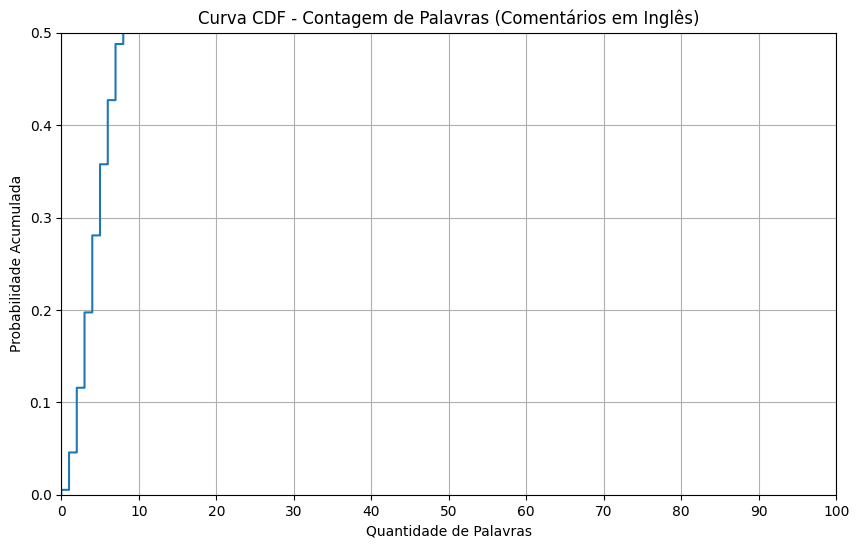

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar o tamanho da figura
plt.figure(figsize=(10, 6))

# Gerar a curva CDF (Empirical Cumulative Distribution Function)
sns.ecdfplot(data=df_comments_en_filtered, x='word_count')

# Limitar o eixo Y (probabilidade) até 0.5
plt.ylim(0, 0.5)

# Reduzir o eixo X (ex: até 100) e definir o intervalo de 10 em 10
plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 10))

# Adicionar títulos e rótulos
plt.title('Curva CDF - Contagem de Palavras (Comentários em Inglês)')
plt.xlabel('Quantidade de Palavras')
plt.ylabel('Probabilidade Acumulada')

# Adicionar grid para facilitar a leitura
plt.grid(True)

# Exibir o gráfico
plt.show()

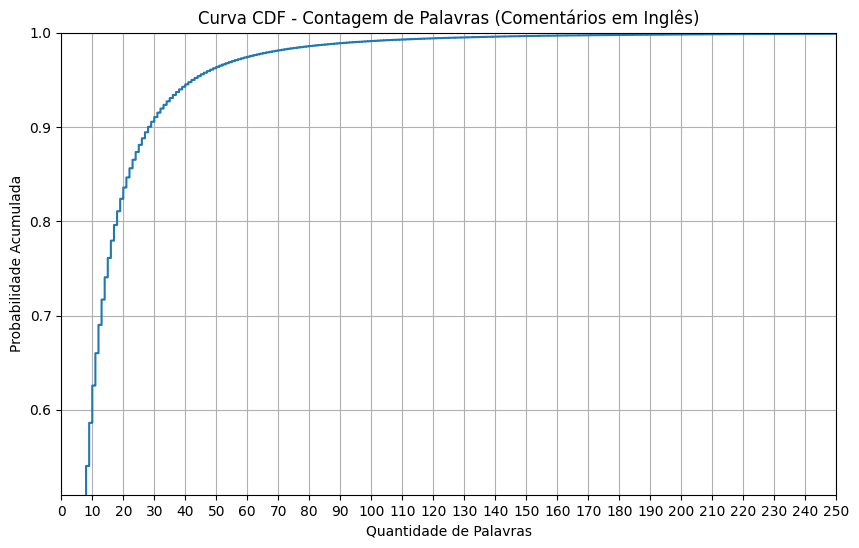

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar o tamanho da figura
plt.figure(figsize=(10, 6))

# Gerar a curva CDF (Empirical Cumulative Distribution Function)
sns.ecdfplot(data=df_comments_en_filtered, x='word_count')

# Limitar o eixo Y (probabilidade) até 0.5
plt.ylim(0.51, 1)

# Reduzir o eixo X (ex: até 100) e definir o intervalo de 10 em 10
plt.xlim(0, 250)
plt.xticks(np.arange(0, 251, 10))

# Adicionar títulos e rótulos
plt.title('Curva CDF - Contagem de Palavras (Comentários em Inglês)')
plt.xlabel('Quantidade de Palavras')
plt.ylabel('Probabilidade Acumulada')

# Adicionar grid para facilitar a leitura
plt.grid(True)

# Exibir o gráfico
plt.show()

In [ ]:
df_comments_en_filtered[['word_count','word_count_regular','word_count_delta']].describe().astype(int)

,word_count,word_count_regular,word_count_delta
count,1697636,1697636,1697636
mean,13,25,12
std,22,43,21
min,0,1,0
25%,4,7,3
50%,8,14,7
75%,15,28,14
max,1026,1881,1119


## Comentários em Português

In [ ]:
file_path = '/content/drive/MyDrive/projeto_youtube/comentarios_pt/comments_cp_pt.csv'

# Read the CSV file into a pandas DataFrame
try:
    # Added engine='python' for more robust parsing and on_bad_lines='skip' to bypass malformed rows
    df_comments_pt = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
    print(f"Successfully loaded {len(df_comments_pt)} rows from comments_cp_en.csv")
    print(df_comments_pt.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please check the path and ensure Google Drive is mounted correctly.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded 9308 rows from comments_cp_en.csv
      video_id                  comment_id parent_id   author_display_name  \
0  ZX70ynObAkA  Ugy1zaBPIFGxwfCQ5Zx4AaABAg       NaN            @EmptyGear   
1  ZX70ynObAkA  UgzITLrBP15fFPjpvPN4AaABAg       NaN         @moncao246642   
2  Zxb8e-Bl7oY  UgzaFkYLTVTs3sfKW_B4AaABAg       NaN         @creytino9312   
3  Zxb8e-Bl7oY  UgxpRkl5FhaGvKRf1gR4AaABAg       NaN   @JonataSamuel-hf6lb   
4  Zxb8e-Bl7oY  UgzBvlotOtr9YsAMVrp4AaABAg       NaN  @VamilsonRicardo-f8r   

          author_channel_id  \
0  UCNeHYDZfny3HUBNfLSMmV9w   
1  UCLJQ2_9C9MZFMuyD9LRoOag   
2  UC4btGt47EFtL_lolWFYETOA   
3  UCClqaZwofIxbctoOLckcpew   
4  UCHAmDVfZtSAjOrUHu1H10yg   

                                                text  like_count  \
0                                           pode não           0   
1                      Vocês ainda não viram nada!!!           0   
2  E além de mostrar o caranguejo assistindo , ai...          23   
3                 

In [ ]:
import pandas as pd

# Define the path to the CSV file
file_path_cp = '/content/drive/MyDrive/projeto_youtube/comentarios_pt/comments_cp.csv'

# Read the CSV file into a pandas DataFrame
try:
    # Added engine='python' for more robust parsing and on_bad_lines='skip' to bypass malformed rows
    df_comments_cp = pd.read_csv(file_path_cp, engine='python', on_bad_lines='skip')
    print(f"Successfully loaded {len(df_comments_cp)} rows from comments_cp.csv")
    print(df_comments_cp.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path_cp}' was not found. Please check the path and ensure Google Drive is mounted correctly.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded 533750 rows from comments_cp.csv
      video_id                  comment_id parent_id  \
0  --0fwuANy1A  UgxN9IMi8eZmg9ZY95V4AaABAg       NaN   
1  --0fwuANy1A  UgwLQ4FB7JtChLxhPXV4AaABAg       NaN   
2  --0fwuANy1A  UgzABERp7tUIL0HDRpV4AaABAg       NaN   
3  --0fwuANy1A  UgyMLHoXKPln4sWbTe94AaABAg       NaN   
4  --0fwuANy1A  Ugwv7kkZRcHAUSS7cRB4AaABAg       NaN   

        author_display_name         author_channel_id  \
0                   @Nufy99  UCaZZhOs1gIAh1waimNv07Jg   
1                   @Nufy99  UCaZZhOs1gIAh1waimNv07Jg   
2  @henriquepoeiramanso6612  UChfBOuXHap-Bnh47khTyfDg   
3              @osmarduarte  UCjqkychsM3kK4FenxO6NVlQ   
4               @Wbevaristo  UCyufwxVQxb9pHPxhGnNQpHQ   

                                                text like_count  \
0      eu bicho que nem e vivo e so um monte de lata          0   
1                               nunca compraria isso          0   
2  Interessante para quem goste e queira deitar m...          0   

In [ ]:
df_comments_cp

,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at
0,--0fwuANy1A,UgxN9IMi8eZmg9ZY95V4AaABAg,NaN,@Nufy99,UCaZZhOs1gIAh1waimNv07Jg,eu bicho que nem e vivo e so um monte de lata,0,2024-03-21T13:08:06Z,2024-03-21T13:08:06Z,none,True,NaN,NaN,2026-04-15T01:22:03Z
1,--0fwuANy1A,UgwLQ4FB7JtChLxhPXV4AaABAg,NaN,@Nufy99,UCaZZhOs1gIAh1waimNv07Jg,nunca compraria isso,0,2024-03-21T13:07:29Z,2024-03-21T13:07:29Z,none,True,NaN,NaN,2026-04-15T01:22:03Z
2,--0fwuANy1A,UgzABERp7tUIL0HDRpV4AaABAg,NaN,@henriquepoeiramanso6612,UChfBOuXHap-Bnh47khTyfDg,Interessante para quem goste e queira deitar m...,0,2024-02-28T12:25:02Z,2024-02-28T12:25:02Z,none,True,NaN,NaN,2026-04-15T01:22:03Z
3,--0fwuANy1A,UgyMLHoXKPln4sWbTe94AaABAg,NaN,@osmarduarte,UCjqkychsM3kK4FenxO6NVlQ,Os chineses são imparáveis!,1,2024-02-27T19:39:49Z,2024-02-27T19:39:49Z,none,True,NaN,NaN,2026-04-15T01:22:03Z
4,--0fwuANy1A,Ugwv7kkZRcHAUSS7cRB4AaABAg,NaN,@Wbevaristo,UCyufwxVQxb9pHPxhGnNQpHQ,"Um ""vira-latas"" caramelo é insubstituível 😅😂",2,2024-02-27T17:37:46Z,2024-02-27T17:37:46Z,none,True,NaN,NaN,2026-04-15T01:22:03Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533745,MVUQ3JrgxYk,Ugx1J1-BVvKqqq5f5I94AaABAg.9nNRhqwO8049nP3wC2t2s1,Ugx1J1-BVvKqqq5f5I94AaABAg,@magnetsec,UCSgpbVNAyS-Me1KnnOAQKXQ,Only the noobs.,0,2023-03-18T12:42:58Z,2023-03-18T12:42:58Z,none,True,NaN,NaN,2026-04-26T17:57:39Z
533746,MVUQ3JrgxYk,UgxBmFFbTrL4V69FQT14AaABAg,NaN,@swargadroy,UCZ8wPTPyTanmT1e5HnPCQBw,First to comment feel good,0,2023-03-17T21:28:14Z,2023-03-17T21:28:14Z,none,True,NaN,NaN,2026-04-26T17:57:39Z
533747,MVUQ3JrgxYk,Ugw3RDyTWf4wjjU909l4AaABAg,NaN,@CertifiedYoutubeBanger,UCyFsFgiEhB26Uv6Prb0kCTw,😢,0,2023-03-17T21:27:43Z,2023-03-17T21:27:43Z,none,True,NaN,NaN,2026-04-26T17:57:39Z
533748,mVwc8qDXYBE,Ugxa28JMJxX5xvoWdgh4AaABAg,NaN,@Firebreathngxreadhead,UCt40sdw501c1pwdoh71qUIg,By bit infinity ETH bug right now\r\nI just ma...,1,2025-05-27T15:14:54Z,2025-05-27T15:14:54Z,none,True,NaN,NaN,2026-04-26T17:57:39Z


In [ ]:
df_combined_pt_comments = pd.concat([df_comments_pt, df_comments_cp], ignore_index=True)
print(f"Combined DataFrame has {len(df_combined_pt_comments)} rows.")
display(df_combined_pt_comments.head())

Combined DataFrame has 543058 rows.


,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at
0,ZX70ynObAkA,Ugy1zaBPIFGxwfCQ5Zx4AaABAg,NaN,@EmptyGear,UCNeHYDZfny3HUBNfLSMmV9w,pode não,0,2023-12-01T01:57:43Z,2023-12-01T01:57:43Z,none,True,NaN,NaN,2026-04-29T11:37:40Z
1,ZX70ynObAkA,UgzITLrBP15fFPjpvPN4AaABAg,NaN,@moncao246642,UCLJQ2_9C9MZFMuyD9LRoOag,Vocês ainda não viram nada!!!,0,2023-12-01T01:49:45Z,2023-12-01T01:49:45Z,none,True,NaN,NaN,2026-04-29T11:37:40Z
2,Zxb8e-Bl7oY,UgzaFkYLTVTs3sfKW_B4AaABAg,NaN,@creytino9312,UC4btGt47EFtL_lolWFYETOA,"E além de mostrar o caranguejo assistindo , ai...",23,2024-02-08T01:16:43Z,2024-02-08T01:16:43Z,none,True,NaN,NaN,2026-04-29T11:37:40Z
3,Zxb8e-Bl7oY,UgxpRkl5FhaGvKRf1gR4AaABAg,NaN,@JonataSamuel-hf6lb,UCClqaZwofIxbctoOLckcpew,Sempre,0,2025-06-02T22:11:31Z,2025-06-02T22:11:31Z,none,True,NaN,NaN,2026-04-29T11:37:40Z
4,Zxb8e-Bl7oY,UgzBvlotOtr9YsAMVrp4AaABAg,NaN,@VamilsonRicardo-f8r,UCHAmDVfZtSAjOrUHu1H10yg,Gostei muito do quero que me ajude enviando...,1,2025-03-25T18:09:25Z,2025-03-25T18:09:25Z,none,True,NaN,NaN,2026-04-29T11:37:40Z


In [ ]:
df_combined_pt_comments[['normalized_text', 'extracted_domains']] = df_combined_pt_comments['text'].apply(
    lambda x: pd.Series(normalize_text_narrative_pt(str(x)))
)

In [ ]:
df_combined_pt_comments

,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at,normalized_text,extracted_domains
0,ZX70ynObAkA,Ugy1zaBPIFGxwfCQ5Zx4AaABAg,NaN,@EmptyGear,UCNeHYDZfny3HUBNfLSMmV9w,pode não,0,2023-12-01T01:57:43Z,2023-12-01T01:57:43Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,pode nao,[]
1,ZX70ynObAkA,UgzITLrBP15fFPjpvPN4AaABAg,NaN,@moncao246642,UCLJQ2_9C9MZFMuyD9LRoOag,Vocês ainda não viram nada!!!,0,2023-12-01T01:49:45Z,2023-12-01T01:49:45Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,voces ainda nao viram nada,[]
2,Zxb8e-Bl7oY,UgzaFkYLTVTs3sfKW_B4AaABAg,NaN,@creytino9312,UC4btGt47EFtL_lolWFYETOA,"E além de mostrar o caranguejo assistindo , ai...",23,2024-02-08T01:16:43Z,2024-02-08T01:16:43Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,alem mostrar caranguejo assistindo ainda mostr...,[]
3,Zxb8e-Bl7oY,UgxpRkl5FhaGvKRf1gR4AaABAg,NaN,@JonataSamuel-hf6lb,UCClqaZwofIxbctoOLckcpew,Sempre,0,2025-06-02T22:11:31Z,2025-06-02T22:11:31Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,sempre,[]
4,Zxb8e-Bl7oY,UgzBvlotOtr9YsAMVrp4AaABAg,NaN,@VamilsonRicardo-f8r,UCHAmDVfZtSAjOrUHu1H10yg,Gostei muito do quero que me ajude enviando...,1,2025-03-25T18:09:25Z,2025-03-25T18:09:25Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,gostei quero ajude enviando email explicacao f...,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543053,MVUQ3JrgxYk,Ugx1J1-BVvKqqq5f5I94AaABAg.9nNRhqwO8049nP3wC2t2s1,Ugx1J1-BVvKqqq5f5I94AaABAg,@magnetsec,UCSgpbVNAyS-Me1KnnOAQKXQ,Only the noobs.,0,2023-03-18T12:42:58Z,2023-03-18T12:42:58Z,none,True,NaN,NaN,2026-04-26T17:57:39Z,only the noobs,[]
543054,MVUQ3JrgxYk,UgxBmFFbTrL4V69FQT14AaABAg,NaN,@swargadroy,UCZ8wPTPyTanmT1e5HnPCQBw,First to comment feel good,0,2023-03-17T21:28:14Z,2023-03-17T21:28:14Z,none,True,NaN,NaN,2026-04-26T17:57:39Z,first to comment feel good,[]
543055,MVUQ3JrgxYk,Ugw3RDyTWf4wjjU909l4AaABAg,NaN,@CertifiedYoutubeBanger,UCyFsFgiEhB26Uv6Prb0kCTw,😢,0,2023-03-17T21:27:43Z,2023-03-17T21:27:43Z,none,True,NaN,NaN,2026-04-26T17:57:39Z,,[]
543056,mVwc8qDXYBE,Ugxa28JMJxX5xvoWdgh4AaABAg,NaN,@Firebreathngxreadhead,UCt40sdw501c1pwdoh71qUIg,By bit infinity ETH bug right now\r\nI just ma...,1,2025-05-27T15:14:54Z,2025-05-27T15:14:54Z,none,True,NaN,NaN,2026-04-26T17:57:39Z,by bit infinity eth bug right now i just made ...,[]


In [ ]:
df_combined_pt_comments['detected_language'] = df_combined_pt_comments['text'].apply(detect_language)

In [ ]:
df_comments_pt_filtered = df_combined_pt_comments[df_combined_pt_comments['detected_language'] == 'pt']
display(df_comments_pt_filtered.head())

,video_id,comment_id,parent_id,author_display_name,author_channel_id,text,like_count,published_at,updated_at,viewer_rating,can_rate,is_public,total_reply_count,collected_at,normalized_text,extracted_domains,detected_language
0,ZX70ynObAkA,Ugy1zaBPIFGxwfCQ5Zx4AaABAg,NaN,@EmptyGear,UCNeHYDZfny3HUBNfLSMmV9w,pode não,0,2023-12-01T01:57:43Z,2023-12-01T01:57:43Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,pode nao,[],pt
1,ZX70ynObAkA,UgzITLrBP15fFPjpvPN4AaABAg,NaN,@moncao246642,UCLJQ2_9C9MZFMuyD9LRoOag,Vocês ainda não viram nada!!!,0,2023-12-01T01:49:45Z,2023-12-01T01:49:45Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,voces ainda nao viram nada,[],pt
2,Zxb8e-Bl7oY,UgzaFkYLTVTs3sfKW_B4AaABAg,NaN,@creytino9312,UC4btGt47EFtL_lolWFYETOA,"E além de mostrar o caranguejo assistindo , ai...",23,2024-02-08T01:16:43Z,2024-02-08T01:16:43Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,alem mostrar caranguejo assistindo ainda mostr...,[],pt
3,Zxb8e-Bl7oY,UgxpRkl5FhaGvKRf1gR4AaABAg,NaN,@JonataSamuel-hf6lb,UCClqaZwofIxbctoOLckcpew,Sempre,0,2025-06-02T22:11:31Z,2025-06-02T22:11:31Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,sempre,[],pt
4,Zxb8e-Bl7oY,UgzBvlotOtr9YsAMVrp4AaABAg,NaN,@VamilsonRicardo-f8r,UCHAmDVfZtSAjOrUHu1H10yg,Gostei muito do quero que me ajude enviando...,1,2025-03-25T18:09:25Z,2025-03-25T18:09:25Z,none,True,NaN,NaN,2026-04-29T11:37:40Z,gostei quero ajude enviando email explicacao f...,[],pt


In [ ]:
print(len(df_combined_pt_comments))
print(len(df_comments_pt_filtered))
print(len(df_combined_pt_comments)-len(df_comments_pt_filtered))
print(len(df_comments_pt_filtered)/len(df_combined_pt_comments))

543058
483845
59213
0.8909637644597814


In [ ]:
# Criar uma cópia explícita para evitar o SettingWithCopyWarning
df_comments_pt_filtered = df_comments_pt_filtered.copy()

# Contar a quantidade de palavras em cada linha de texto normalizado
df_comments_pt_filtered['word_count'] = df_comments_pt_filtered['normalized_text'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

df_comments_pt_filtered['word_count_regular'] = df_comments_pt_filtered['text'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
df_comments_pt_filtered['word_count_delta'] = df_comments_pt_filtered['word_count_regular'] - df_comments_pt_filtered['word_count']
# Exibir as primeiras linhas com a nova coluna
display(df_comments_pt_filtered[['normalized_text', 'word_count','word_count_regular','word_count_delta']].head())

,normalized_text,word_count,word_count_regular,word_count_delta
0,pode nao,2,2,0
1,voces ainda nao viram nada,5,5,0
2,alem mostrar caranguejo assistindo ainda mostr...,10,16,6
3,sempre,1,1,0
4,gostei quero ajude enviando email explicacao f...,13,23,10


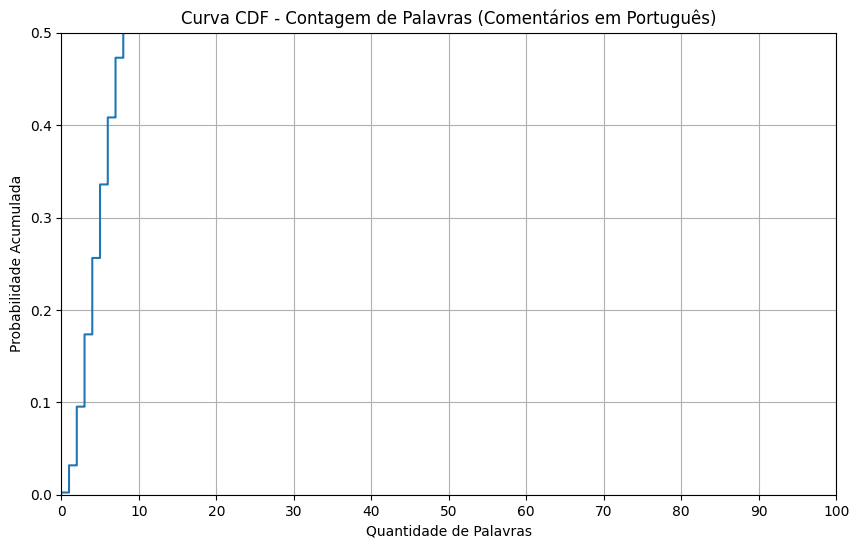

In [ ]:
# Configurar o tamanho da figura
plt.figure(figsize=(10, 6))

# Gerar a curva CDF (Empirical Cumulative Distribution Function)
sns.ecdfplot(data=df_comments_pt_filtered, x='word_count')

# Limitar o eixo Y (probabilidade) até 0.5
plt.ylim(0, 0.5)

# Reduzir o eixo X (ex: até 100) e definir o intervalo de 10 em 10
plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 10))

# Adicionar títulos e rótulos
plt.title('Curva CDF - Contagem de Palavras (Comentários em Português)')
plt.xlabel('Quantidade de Palavras')
plt.ylabel('Probabilidade Acumulada')

# Adicionar grid para facilitar a leitura
plt.grid(True)

# Exibir o gráfico
plt.show()

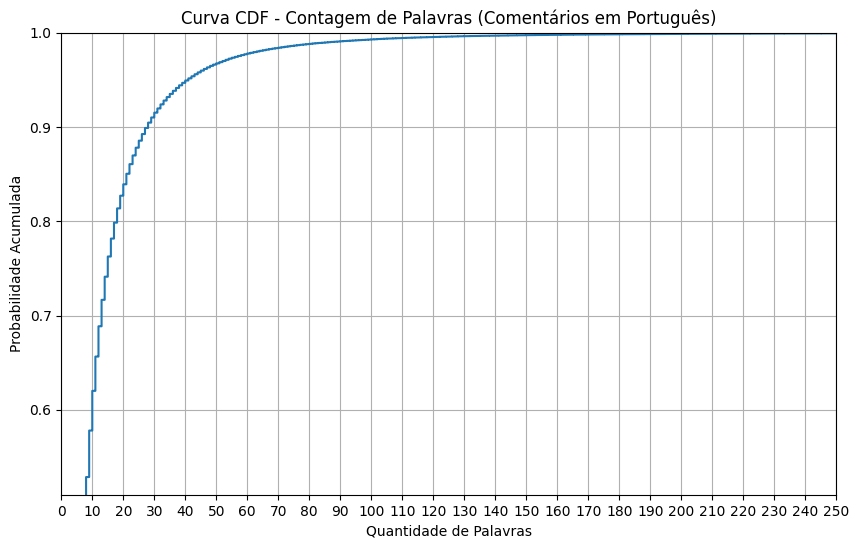

In [ ]:
# Configurar o tamanho da figura
plt.figure(figsize=(10, 6))

# Gerar a curva CDF (Empirical Cumulative Distribution Function)
sns.ecdfplot(data=df_comments_pt_filtered, x='word_count')

# Limitar o eixo Y (probabilidade) até 0.5
plt.ylim(0.51, 1)

# Reduzir o eixo X (ex: até 100) e definir o intervalo de 10 em 10
plt.xlim(0, 250)
plt.xticks(np.arange(0, 251, 10))

# Adicionar títulos e rótulos
plt.title('Curva CDF - Contagem de Palavras (Comentários em Português)')
plt.xlabel('Quantidade de Palavras')
plt.ylabel('Probabilidade Acumulada')

# Adicionar grid para facilitar a leitura
plt.grid(True)

# Exibir o gráfico
plt.show()

In [ ]:
df_comments_pt_filtered[['word_count','word_count_regular','word_count_delta']].describe()

,word_count,word_count_regular,word_count_delta
count,483845.000000,483845.000000,483845.000000
mean,13.243902,23.206554,9.962651
std,19.595431,35.285377,15.993223
min,0.000000,1.000000,0.000000
25%,4.000000,7.000000,3.000000
50%,8.000000,14.000000,6.000000
75%,15.000000,26.000000,11.000000
max,910.000000,1743.000000,877.000000
